In [1]:
! pip install xgboost shap lightgbm

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 9.3 MB/s eta 0:00:11
   - -------------------------------------- 3.4/101.7 MB 10.6 MB/s eta 0:00:10
   -- ------------------------------------- 6.0/101.7 MB 10.5 MB/s eta 0:00:10
   --- ------------------------------------ 8.9/101.7 MB 11.3 MB/s eta 0:00:09
   ---- ----------------------------------- 11.8/101.7 MB 11.9 MB/s eta 0:00:08
   ----- ---------------------------------- 13.6/101.7 MB 11.4 MB/s eta 0:00:08
   ------ --------------------------------- 15.7/101.7 MB 11.5 MB/s eta 0:00:08
   ------- -------------------------------- 18.4/101.7 MB 11.5 MB/s eta 0:00:08
   -------- ------------------------------- 21.0/101.7 MB 11.5 MB/s eta 0:00:08
   --------- ------------------------------ 23.6/101.7 MB 11.7 MB/s eta 0:00:07
   ---------- ----------------------------- 26.0/101.7 MB 11.7 MB/s eta 0:00:07
   ----------- ---------------------------- 28.6/101.7

# SVM 주요 개념
## Hyperplane (결정경계)
: 데이터를 두 개 이상 클래스로 구분하는 경계선
## Support Vector
: 결정경계와 가장 가까운 지점에 위치한 데이터 포인트 : svm은 이 포인트들만으로 결정 경계 학습 수행
## Margin(여유 거리)
: 두 클래스 사이의 최소거리 : 마진이 넓을수록 일반화 성능이 좋아짐

In [44]:
import numpy as np                                                  # 수치연산
import pandas as pd                                                 # 데이터 처리
import matplotlib.pylab as plt                                      # 시각화
from sklearn import datasets                                        # Iris 데이터셋 가져오기
from sklearn.model_selection import train_test_split                 # 데이터 분할 함수
from sklearn.preprocessing import StandardScaler                    # 표준화(스케일링)  
from sklearn.svm import SVC                                         # svm 분류 모델
from sklearn.metrics import classification_report, confusion_matrix # 평가

In [19]:
iris = datasets.load_iris()
X = iris.data          # feature 데이터 
y = iris.target        # target : 품종

In [20]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [27]:
# 학습용/테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42             #학습 데이터 8 : 2 테스트 데이터 #
)

In [28]:
# 스케일링(표준화)   < -- svm은 거리 기반 알고리즘이므로 스케일링 필요

scaler = StandardScaler()                             # 표준화 객체 생성
X_train_scaled = scaler.fit_transform(X_train)        # 학습데이터 기준으로 변환
X_test_scaled = scaler.fit_transform(X_test)          # 테스트 데이터 기준으로 변환

In [29]:
# svm 모델 생성 및 학습
svm_clf = SVC(kernel='rbf', C=1.0, gamma='scale')
# kernel=rbf --> 비선형 데이터에 적합한 RBF 커널 사용 / C : 오차 허용범위 / gamma : 결정 경계의 유연성(커질수록 복잡해짐)

svm_clf.fit(X_train_scaled, y_train)   # 모델 학습 수행

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [30]:
## 예측 수행
y_pred = svm_clf.predict(X_test_scaled)   # 테스트 데이터를 예측

In [35]:
## 평가 지표 출력
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))    # matrix 행렬 출력

print('\Classification Report')
print(classification_report(y_test, y_pred))   # precision, recall 등 출력

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]
\Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [39]:
## 예측 결과 시각화
# 차원을 2개로 축소해서 분류 경계 시각화
from sklearn.decomposition import PCA
pca = PCA(n_components=2)    # 2차원으로 축소
X_test_pca = pca.fit_transform(X_test_scaled)

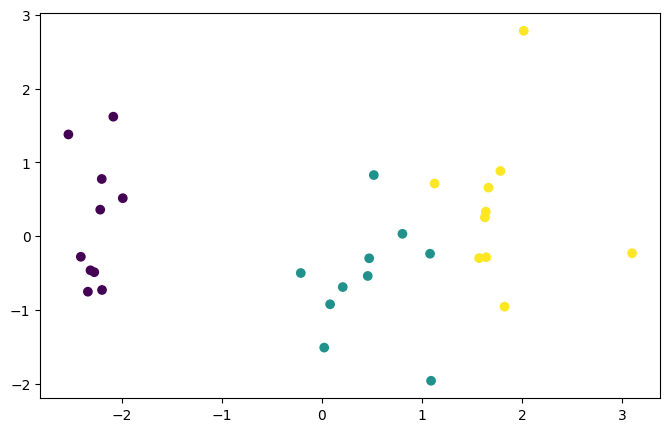

In [45]:
## 실제 값 vs 예측 값 비교 시각화
plt.figure(figsize=(8,5))
plt.scatter(
    X_test_pca[:,0],   #PCA 1차원 축
    X_test_pca[:,1],   #PCA 2차원 축
    c=y_pred,
    cmap='viridis',
    marker='o',
    label='Predicted'
)

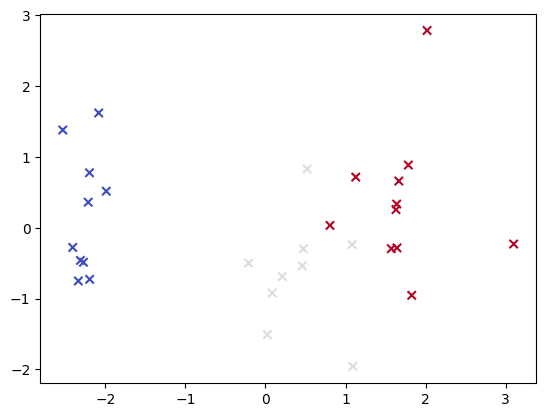

In [46]:
# 실제 라벨 위치를 점선으로 표시
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    cmap='coolwarm',
    marker='x',
    label='Actual'
)

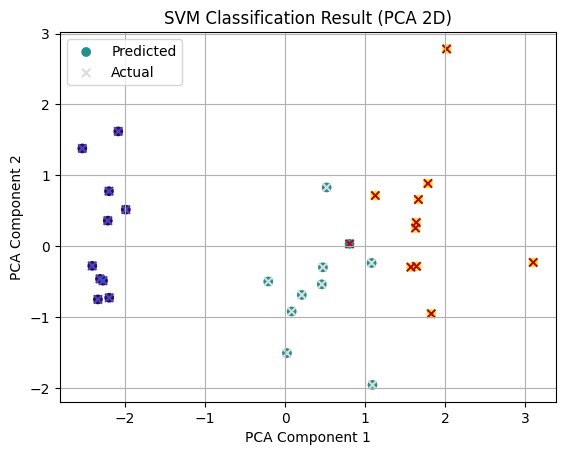

In [47]:
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', marker='o', label='Predicted')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', marker='x', label='Actual')
plt.title("SVM Classification Result (PCA 2D)")      # 그래프 제목
plt.xlabel("PCA Component 1")                        # x축 이름
plt.ylabel("PCA Component 2")                        # y축 이름
plt.legend()                                         # 범례 표시
plt.grid(True)                                       # 격자 추가
plt.show()

# Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

# 데이터 가져오기

In [49]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

# 학습/ 테스트 데이터 분리

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# random forest 모델 생성

In [52]:
rf_clf = RandomForestClassifier(
    n_estimators=100, # 생성할 결정트리 개수
    max_depth=None,   # 트리깊이를 제한하지 않음  -> 자동으로 최적 깊이 탐색
    random_state=42,  # 랜덤시드 고정
    n_jobs = -1       #  모든 cpu 코어를 사용하여 학습 속도를 향상
)

## 모델 학습 수행

In [54]:
rf_clf.fit(X_train, y_train)  # 학습 데이터 사용해서 모델을 학습

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [55]:
y_pred = rf_clf.predict(X_test)

In [56]:
## 평가 지표 출력
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))     # matrix 행렬 출력

print('\n Classification Report')
print(classification_report(y_test, y_pred))  # precision, recall 등 출력

Confusion Matrix
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

 Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



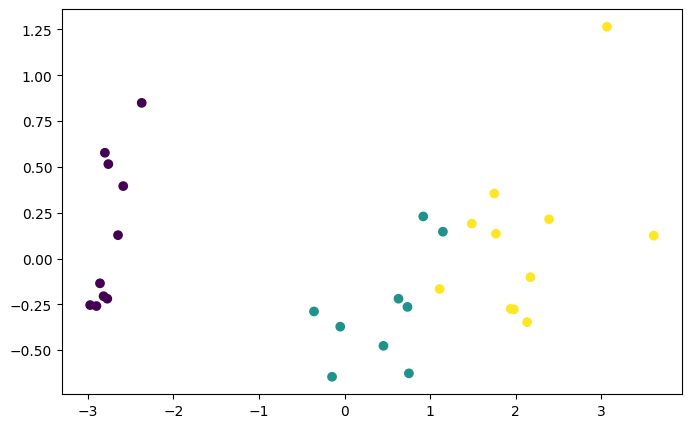

In [60]:
# PCA를 이용해 2차원 축소
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test)

plt.figure(figsize=(8,5))
plt.scatter(
    X_test_pca[:,0],   #PCA 1차원 축
    X_test_pca[:,1],   #PCA 2차원 축
    c=y_pred,
    cmap='viridis',
    marker='o',
    label='Predicted'
)

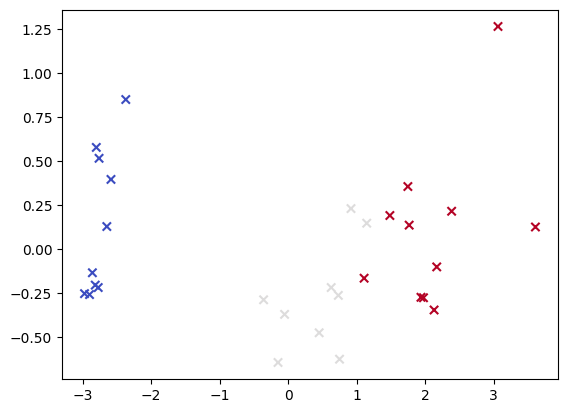

In [61]:
# 실제 라벨 위치를 점선으로 표시
plt.scatter(
    X_test_pca[:, 0],
    X_test_pca[:, 1],
    c=y_test,
    cmap='coolwarm',
    marker='x',
    label='Actual'
)

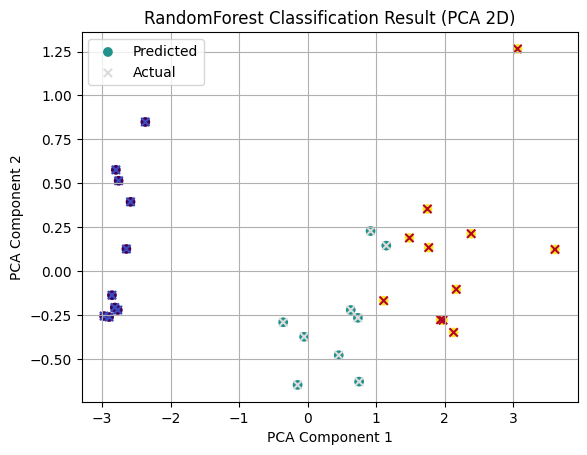

In [62]:
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_pred, cmap='viridis', marker='o', label='Predicted')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='coolwarm', marker='x', label='Actual')
plt.title("RandomForest Classification Result (PCA 2D)")      # 그래프 제목
plt.xlabel("PCA Component 1")                        # x축 이름
plt.ylabel("PCA Component 2")                        # y축 이름
plt.legend()                                         # 범례 표시
plt.grid(True)                                       # 격자 추가
plt.show()